## ***Data Cleaning and Feature Engineering***

### Overview
This notebook focuses on cleaning the raw scraped dataset, handling missing and inconsistent values, transforming columns into usable formats, and creating new meaningful features for analysis and machine learning.

### Workflow
- Load raw CSV dataset
- Remove duplicates and irrelevant records
- Handle missing values
- Clean text and numerical columns
- Standardize product attributes
- Convert data types
- Extract and engineer new features from existing columns
- Prepare final dataset for modeling

### Feature Engineering Examples
- Extract capacity values from product titles
- Identify appliance type from descriptions
- Convert price strings into numerical format
- Generate categorical features from specifications
- Create binary indicators for premium features

### Technologies Used
- Python
- pandas
- NumPy
- Regular Expressions (re)

### Output
The processed dataset is exported as a cleaned CSV file ready for:
- Exploratory Data Analysis (EDA)
- Machine Learning pipelines
- Price prediction models
- Business insights and visualization

In [1]:
# import libraries
import pandas as pd
import numpy as np
import re

In [2]:
# load the parsed of air conditioners 
raw_df = pd.read_csv("D:/Study/data_science/underpriced-listing-predictor/data/02.parsed/ac_full_parsed.csv")

print(raw_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   name      1020 non-null   str  
 1   price     1020 non-null   str  
 2   rating    1020 non-null   str  
 3   ac_type   1020 non-null   str  
 4   capacity  1020 non-null   str  
 5   features  1020 non-null   str  
dtypes: str(6)
memory usage: 294.6 KB
None


In [4]:
print(raw_df.head())

                                                name    price  \
0  Whirlpool SAI18B52MCD1 1.5 Ton 5 Star Inverter...  ₹24,990   
1  Carrier CAI18ER3R34F0 1.5 Ton 3 Star 2024 Inve...  ₹22,990   
2  O General ASGG18CGAB-B 1.5 Ton 5 Star Inverter...  ₹67,990   
3  Haier HSU18V-POW5BN-INV 1.5 Ton 5 Star 2025 In...  ₹37,990   
4  Voltas 183V XAZX 1.5 Ton 3 Star Split Inverter AC  ₹22,990   

            rating   ac_type          capacity  \
0  --rating: 4.65;  Split AC  1.5 Ton Capacity   
1  --rating: 4.55;  Split AC  1.5 Ton Capacity   
2   --rating: 4.1;  Split AC  1.5 Ton Capacity   
3  --rating: 4.55;  Split AC  1.5 Ton Capacity   
4  --rating: 4.55;  Split AC  1.5 Ton Capacity   

                                            features  
0  ['Air Swing, Auto Restart', 'Turbo Mode, Sleep...  
1  ['Hidden Panel Display', '2-Way Air Swing, Aut...  
2  ['LED Panel Display', 'Air Swing, Auto Restart...  
3  ['Hidden Panel Display', '4-Way Air Swing, Aut...  
4  ['Air Swing, Auto Restart', 'D

In [ ]:
# Let us check for null values
print(raw_df.isnull().sum()) # Zero null values in our data

name        0
price       0
rating      0
ac_type     0
capacity    0
features    0
dtype: int64


### ***Cleaning Price Column***

In [27]:
raw_df ['price'] = (raw_df['price'].str.replace({'₹':"" , ',':""}))

In [30]:
raw_df['price'] = raw_df['price'].astype(np.int64)

print(raw_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   name      1020 non-null   str  
 1   price     1020 non-null   int64
 2   rating    1020 non-null   str  
 3   ac_type   1020 non-null   str  
 4   capacity  1020 non-null   str  
 5   features  1020 non-null   str  
dtypes: int64(1), str(5)
memory usage: 285.7 KB
None


### ***Cleaning Ratings Column***

In [ ]:
raw_df['rating'] = raw_df['rating'].str.split(': ').str[1].str[:-1].str.strip().astype(np.float32)

print(raw_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      1020 non-null   str    
 1   price     1020 non-null   int64  
 2   rating    1020 non-null   float32
 3   ac_type   1020 non-null   str    
 4   capacity  1020 non-null   str    
 5   features  1020 non-null   str    
dtypes: float32(1), int64(1), str(4)
memory usage: 267.4 KB
None


### ***Cleaning AC Type Column***

In [ ]:
raw_df['ac_type'] = raw_df['ac_type'].str.split(" ").str[0].astype('str')
print(raw_df.info())

<class 'pandas.DataFrame'>
Index: 1012 entries, 0 to 1019
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      1012 non-null   str    
 1   price     1012 non-null   int64  
 2   rating    1012 non-null   float32
 3   ac_type   1012 non-null   str    
 4   capacity  1012 non-null   float32
 5   features  1012 non-null   str    
dtypes: float32(2), int64(1), str(3)
memory usage: 251.3 KB
None


In [46]:
print(raw_df['ac_type'].value_counts())

ac_type
Split       905
Window      107
Cassette      4
Tower         2
Portable      1
1.5           1
Name: count, dtype: int64


**There are categories of ACs which are very less in comparison to Split or Window**
- What we can do is we can use a threshold for Different categories of ACs
- Suppose We set Threshold = 100 i.e AC Category >100 will be kept other ACs will be dropped automatically.

**This helps us when we scale the data by scraping more (if needed), then our pipeline will remain perfect.**

In [ ]:
counts = raw_df['ac_type'].value_counts()

valid_types = counts[counts >= 100].index

raw_df = raw_df[raw_df['ac_type'].isin(valid_types)]
print(raw_df.ac_type.value_counts()) # Only two Categories are left for now!!

ac_type
Split     905
Window    107
Name: count, dtype: int64


### ***Cleaning Capacity Column***

In [70]:
raw_df['capacity'] = raw_df['capacity'].str.split(" ").str[0].astype(np.float32)

print(raw_df.info())

<class 'pandas.DataFrame'>
Index: 1012 entries, 0 to 1019
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      1012 non-null   str    
 1   price     1012 non-null   int64  
 2   rating    1012 non-null   float32
 3   ac_type   1012 non-null   object 
 4   capacity  1012 non-null   float32
 5   features  1012 non-null   str    
dtypes: float32(2), int64(1), object(1), str(2)
memory usage: 246.3+ KB
None


Axes(0.125,0.11;0.775x0.77)


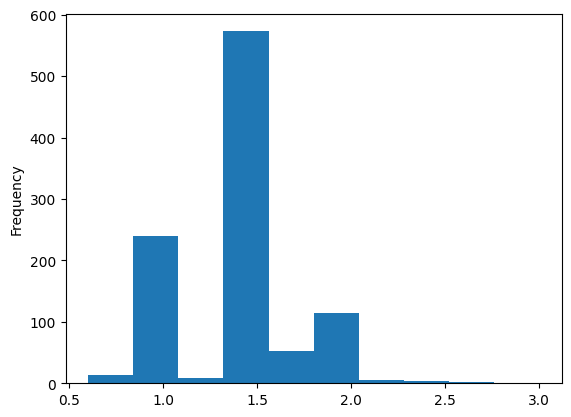

In [75]:
print(raw_df['capacity'].plot(kind='hist'))

In [76]:
print(raw_df['capacity'].value_counts())

capacity
1.50    568
1.00    236
2.00    113
1.60     28
1.80     16
0.80     11
1.70      6
1.40      5
1.20      4
2.50      4
0.90      3
1.30      3
2.60      2
2.20      2
0.75      1
2.15      1
0.60      1
2.25      1
1.75      1
2.10      1
1.65      1
3.00      1
0.70      1
1.25      1
2.02      1
Name: count, dtype: int64


- This rounds the data into standard sizes !! capacity is a numerical quantity so Do not interpret it as Categorical Feature

In [81]:
import numpy as np

def round_to_standard_capacity(val):
    # Standard AC sizes in the market
    standard = [0.75, 1.0, 1.2, 1.5, 1.6, 1.8, 2.0, 2.5, 3.0]
    return min(standard, key=lambda x: abs(x - val))

raw_df['capacity'] = raw_df['capacity'].apply(round_to_standard_capacity)

print(raw_df['capacity'].value_counts())

capacity
1.50    573
1.00    239
2.00    119
1.60     29
1.80     23
0.75     14
1.20      8
2.50      6
3.00      1
Name: count, dtype: int64
